# 📊 Stock Market Data Analyzer
# Python + Pandas + Technical Indicators + Visualization

In [69]:
%pip install pandas numpy matplotlib yfinance ta

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import yfinance as yf
import pandas as pd

df = yf.download("AAPL", start="2023-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from ta.trend import SMAIndicator, EMAIndicator
from ta.momentum import RSIIndicator

In [72]:


ticker = "AAPL"   # you can change: TSLA, MSFT, INFY.NS

data = yf.download(ticker, start="2023-01-01", end="2025-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096016,128.833995,122.210219,128.223785,112117500
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600
2023-01-05,123.046814,125.753411,122.790923,125.123513,80962700
2023-01-06,127.574196,128.233619,122.918854,124.021180,87754700
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800


In [73]:
import yfinance as yf
import pandas as pd

df = yf.download("AAPL", start="2023-01-01", end="2025-01-01")

# 🔥 FORCE 1D SERIES (THIS IS THE FIX)
close = df["Close"].squeeze()

print(type(close))
print(close.shape)

[*********************100%***********************]  1 of 1 completed

<class 'pandas.Series'>
(502,)


In [74]:
import yfinance as yf

data = yf.download("AAPL", start="2023-01-01", end="2025-01-01")

# ✅ convert to Series
close = data["Close"].copy()
close = close.squeeze()

close.head()

[*********************100%***********************]  1 of 1 completed


Date
2023-01-03    123.096016
2023-01-04    124.365662
2023-01-05    123.046814
2023-01-06    127.574196
2023-01-09    128.095856
Name: AAPL, dtype: float64

In [75]:
df["SMA20"] = SMAIndicator(close=close, window=20).sma_indicator()
df["EMA20"] = EMAIndicator(close=close, window=20).ema_indicator()
df["EMA50"] = EMAIndicator(close=close, window=50).ema_indicator()
df["RSI"] = RSIIndicator(close=close, window=14).rsi()

df.tail()

Price,Close,High,Low,Open,Volume,SMA20,EMA20,EMA50,RSI
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2024-12-24,256.797241,256.807166,253.903032,254.101958,23234700,244.955387,245.328335,237.010488,75.750309
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100,246.146878,246.498277,237.818419,76.452883
2024-12-27,254.201385,257.294505,251.685132,256.429206,42355300,247.174266,247.231907,238.460888,67.626296
2024-12-30,250.829803,252.122744,249.387684,250.859639,35557500,247.913727,247.574564,238.945944,60.225598
2024-12-31,249.059464,251.903926,248.074837,251.068493,39480700,248.452286,247.715983,239.342552,56.715902


In [76]:
df.dropna(inplace=True)

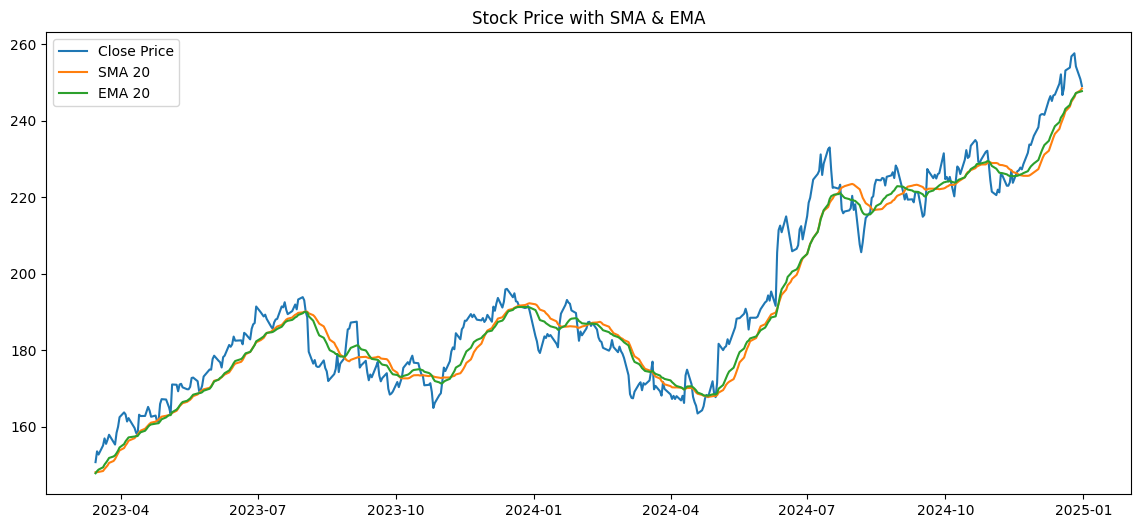

In [77]:
plt.figure(figsize=(14,6))

plt.plot(df["Close"], label="Close Price")
plt.plot(df["SMA20"], label="SMA 20")
plt.plot(df["EMA20"], label="EMA 20")

plt.title("Stock Price with SMA & EMA")
plt.legend()
plt.show()

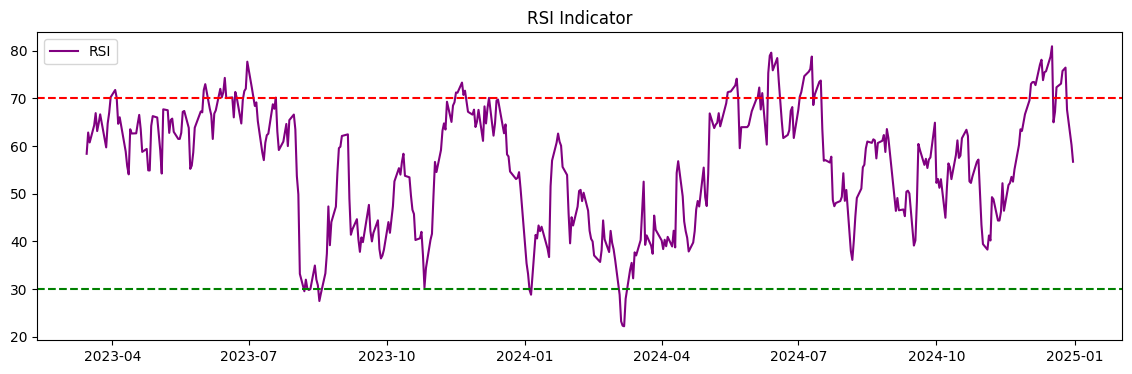

In [78]:
plt.figure(figsize=(14,4))
plt.plot(df["RSI"], label="RSI", color="purple")
plt.axhline(70, linestyle="--", color="red")
plt.axhline(30, linestyle="--", color="green")

plt.title("RSI Indicator")
plt.legend()
plt.show()

In [79]:
print("Max Close Price:", df["Close"].max())
print("Min Close Price:", df["Close"].min())
print("Average Close Price:", df["Close"].mean())

Max Close Price: Ticker
AAPL    257.612732
dtype: float64
Min Close Price: Ticker
AAPL    150.805252
dtype: float64
Average Close Price: Ticker
AAPL    193.004441
dtype: float64
